# Case Analítico: LogiPrime & RotaSul
## Notebook 01: Avaliação de Integridade e Qualidade dos Dados

**Objetivo:** Avaliar a integridade e confiabilidade das bases de dados, identificar os principais problemas de qualidade e sua representatividade. Indicar propostas de correção e validar a atualização da base para as análises seguintes.

Para garantir a transparência da análise, este notebook investiga os dados brutos recém-ingeridos da camada `02_interim`, diagnostica as anomalias originais, apresenta as regras de negócio adotadas para correção (registradas no nosso pipeline automático) e, por fim, valida o resultado final na base tratada na camada `03_processed`.

In [1]:
# Importação das bibliotecas necessárias
#pip install polars pandas matplotlib seaborn
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Configurações visuais para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

# Definindo os caminhos relativos com base na estrutura de pastas apresentada
path_rotasul_interim = "../data/02_interim/rotasul_ingested.parquet"
path_logiprime_interim = "../data/02_interim/logiprime_ingested.parquet"
path_dados_limpos = "../data/03_processed/dados_limpos.parquet"
path_relatorio = "../data/03_processed/relatorio_qualidade.json"

# Lendo a base 'Antes' (unindo os arquivos interim para diagnóstico da base bruta)
df_bruto = pl.concat([
    pl.read_parquet(path_rotasul_interim),
    pl.read_parquet(path_logiprime_interim)
], how="vertical")

# Lendo a base 'Depois' (tratada pelo script clean_data.py)
df_limpo = pl.read_parquet(path_dados_limpos)

# 1. Deduplicação de registros
print(f"Registros antes da deduplicação: {df_bruto.height:,}")
print(f"Registros após deduplicação: {df_limpo.height:,}")

# 2. Preenchimento de nulos em km_ate_ponto, tempo_ate_ponto_min e tempo_trecho_min
def count_nulls(df, col):
    return df[col].is_null().sum() if col in df.columns else None

for col in ["km_ate_ponto", "tempo_ate_ponto_min", "tempo_trecho_min"]:
    nulos_bruto = count_nulls(df_bruto, col)
    nulos_limpo = count_nulls(df_limpo, col)
    if nulos_bruto is not None and nulos_limpo is not None:
        print(f"Nulos em {col} - Bruto: {nulos_bruto:,} | Limpo: {nulos_limpo:,}")

# 3. Remoção das colunas de erro negativo
for col in ["erro_negativo_km", "erro_negativo_tempo"]:
    existe_bruto = col in df_bruto.columns
    existe_limpo = col in df_limpo.columns
    print(f"Coluna '{col}' existe no bruto? {existe_bruto} | Existe no limpo? {existe_limpo}")

# 4. Remoção de colunas _txt
colunas_txt_bruto = [c for c in df_bruto.columns if c.endswith('_txt')]
colunas_txt_limpo = [c for c in df_limpo.columns if c.endswith('_txt')]
print(f"Qtd colunas _txt no bruto: {len(colunas_txt_bruto)} | no limpo: {len(colunas_txt_limpo)}")

Registros antes da deduplicação: 3,598,419
Registros após deduplicação: 3,455,659
Nulos em km_ate_ponto - Bruto: 10,394 | Limpo: 0
Nulos em tempo_ate_ponto_min - Bruto: 10,328 | Limpo: 0
Nulos em tempo_trecho_min - Bruto: 10,337 | Limpo: 0
Coluna 'erro_negativo_km' existe no bruto? True | Existe no limpo? False
Coluna 'erro_negativo_tempo' existe no bruto? True | Existe no limpo? False
Qtd colunas _txt no bruto: 3 | no limpo: 0


### 1. Diagnóstico: Principais Problemas de Qualidade (O Cenário "Antes")

Investigamos três frentes principais de degradação da informação exigidas para avaliação de confiabilidade:
1. **Completude (Missing Values):** Presença de valores nulos em colunas vitais para cálculo financeiro e operacional.
2. **Consistência Física (Outliers/Anomalias):** Valores que violam regras lógicas, como tempo de trecho ou quilometragem negativos.
3. **Integridade Lógica (Métricas Agregadas vs. Granulares):** Divergência entre os totais declarados na rota (ex: `peso_kg_total_rota`) e a soma real das entregas individuais (`peso_kg_entrega`), um problema crítico de confiabilidade.

#### 1.1 Avaliação de Valores Nulos

,Qtd_Nulos,Representatividade (%)
km_trecho,10395,0.288877
km_trecho_txt,10395,0.288877
km_ate_ponto,10394,0.288849
km_ate_ponto_txt,10394,0.288849
tempo_total_rota_min,10375,0.288321
tempo_trecho_min,10337,0.287265
tempo_ate_ponto_min,10328,0.287015
km_total_rota,10265,0.285264
km_total_rota_txt,10265,0.285264


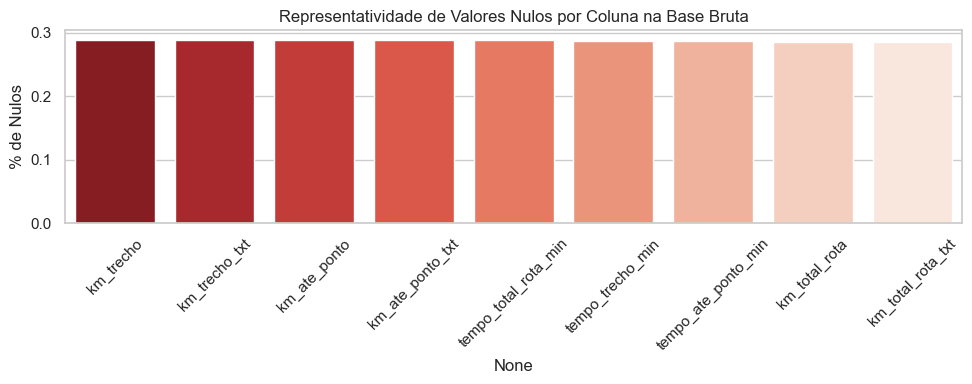

In [2]:
# 1.1 Avaliação de Nulos
nulos_df = df_bruto.null_count().to_pandas().T
nulos_df.columns = ['Qtd_Nulos']
nulos_df['Representatividade (%)'] = (nulos_df['Qtd_Nulos'] / df_bruto.height) * 100
nulos_df = nulos_df[nulos_df['Qtd_Nulos'] > 0].sort_values(by='Qtd_Nulos', ascending=False)

display(nulos_df)

if not nulos_df.empty:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=nulos_df, x=nulos_df.index, y='Representatividade (%)', palette='Reds_r')
    plt.title('Representatividade de Valores Nulos por Coluna na Base Bruta')
    plt.xticks(rotation=45)
    plt.ylabel('% de Nulos')
    plt.tight_layout()
    plt.show()

Observando a volumetria, notamos a presença de colunas com o sufixo `_txt`. Estas colunas parecem ser extrações brutas do sistema que já possuem correspondentes numéricos formatados. Além disso, precisamos mapear o comportamento dos nulos nas métricas acumuladas (ex: `km_ate_ponto`).

In [3]:
# Mapeando colunas _txt (Redundantes)
colunas_txt = [col for col in df_bruto.columns if col.endswith('_txt')]
print(f"Colunas redundantes identificadas para descarte: {colunas_txt}\n")

# Detalhando os nulos restantes que precisam de tratamento lógico
nulos_detalhados = df_bruto.select([col for col in df_bruto.columns if col not in colunas_txt]).null_count().to_pandas().T
nulos_detalhados.columns = ['Qtd_Nulos']
nulos_detalhados = nulos_detalhados[nulos_detalhados['Qtd_Nulos'] > 0]
print("Nulos em colunas essenciais que exigem tratamento:")
display(nulos_detalhados)

Colunas redundantes identificadas para descarte: ['km_trecho_txt', 'km_ate_ponto_txt', 'km_total_rota_txt']

Nulos em colunas essenciais que exigem tratamento:


,Qtd_Nulos
km_trecho,10395
km_ate_ponto,10394
tempo_trecho_min,10337
tempo_ate_ponto_min,10328
km_total_rota,10265
tempo_total_rota_min,10375


#### 1.2 Hipóteses Para Análise e Regras de Negócio

Ao fazer uma análise inicial para levantamento e entendimento a respeito dos dados nulos, as seguintes colunas demostraram a nescessidade de avaliação: 
- km_trecho
- km_ate_ponto
- tempo_trecho_min
- tempo_ate_ponto_min
- km_total_rota
- tempo_total_rota_min

Afim de entender do por que destas anomalias apontadas, e poder criar **regras de negócio** que fossem capaz de realizar um tratamento de dados adequado na base de dados durante, a analise seguiu a partir de 4 hipóteses para tratamentos destas colunas e assim seguir com a análise, sendo elas:

a) Perfil de "Registros Fantasmas" (A correlação de Nulos): Os números de nulos em km_trecho (10.395), km_ate_ponto (10.394) e tempo_total_rota_min (10.375) são quase idêntico. Isso indica que não são falhas aleatórias, mas sim falhas sistêmicas de log. Cerca de 10.300 registros são "vazios" de métricas físicas, apesar de terem codigo_rota e pdv_id. A hipótese quanto a esses dados é que esses registros pertencem a um tipo específico de veículo ou região. Se forem rotas de "transferência" (entre centros de distribuição), elas podem não ter sido mapeadas pelo roteirizador da mesma forma que as entregas finais.


In [4]:
# A. Investigação de Registros Fantasmas (Correlação de Nulos)
print("--- Bloco A: Análise de Registros Fantasmas ---")

# Filtrando registros onde métricas de trecho são nulas
df_fantasmas = df_bruto.filter(
    pl.col("km_trecho").is_null() | 
    pl.col("tempo_trecho_min").is_null()
)

print(f"Total de registros fantasmas: {df_fantasmas.height:,}")

# Agrupando por Empresa, Regional e Tipo de Veículo para identificar padrões
perfil_fantasmas = df_fantasmas.group_by(["empresa", "uf", "tipo_veiculo"]).agg(
    pl.len().alias("qtd_ocorrências")
).sort("qtd_ocorrências", descending=True)

display(perfil_fantasmas)

perfil_fantasmas.write_csv("../data/05_analysis/perfil_fantasmas.csv")


--- Bloco A: Análise de Registros Fantasmas ---
Total de registros fantasmas: 20,705


empresa,uf,tipo_veiculo,qtd_ocorrências
str,str,str,u32
"""LogiPrime""","""SP""","""VUC""",6769
"""LogiPrime""","""SP""","""TOCO""",4507
"""LogiPrime""","""RJ""","""VUC""",2917
"""LogiPrime""","""RJ""","""TOCO""",1941
"""RotaSul""","""PR""","""TRUCK""",1327
"""RotaSul""","""SC""","""TRUCK""",1006
"""RotaSul""","""RS""","""TRUCK""",958
"""RotaSul""","""PR""","""CARRETA""",484
"""RotaSul""","""SC""","""CARRETA""",400


Os 20.705 registros sem métricas físicas (especialmente em VUCs da LogiPrime) indicam falhas de integração de sensores urbanos. Como representam < 1% da base total (~3M), o risco de viés é baixo. Em vez de preencher com 0.0 (o que baixaria artificialmente as médias de KM/tempo), o ideal é manter como nulo ou aplicar a média da categoria (`tipo_veiculo` x `uf`) se houver necessidade de análise volumétrica total.

b) KM Total (Divergência de 15.12%): Em logística, o km_total_rota (declarado) geralmente inclui o Retorno à Base (do último cliente de volta ao galpão), enquanto a soma de km_trecho (granular) costuma parar no último ponto de entrega. A hipótese a ser trabalhada sobre este dados é realizar um teste para ver se km_total_rota - soma(km_trecho) resulta sempre em um valor positivo. Se sim, essa "divergência" é na verdade o custo de retorno, vital para o cálculo de combustível (Opex). Sobrescrever esse valor com a soma simples antes de entender isso subestimaria o custo real.


--- Bloco B: Análise de Retorno à Base ---
Rotas com 'Km de Retorno' provável (Informado > Soma): 13,357 (8.51%)
Rotas com erro de truncagem (Soma > Informado): 10,376 (6.61%)


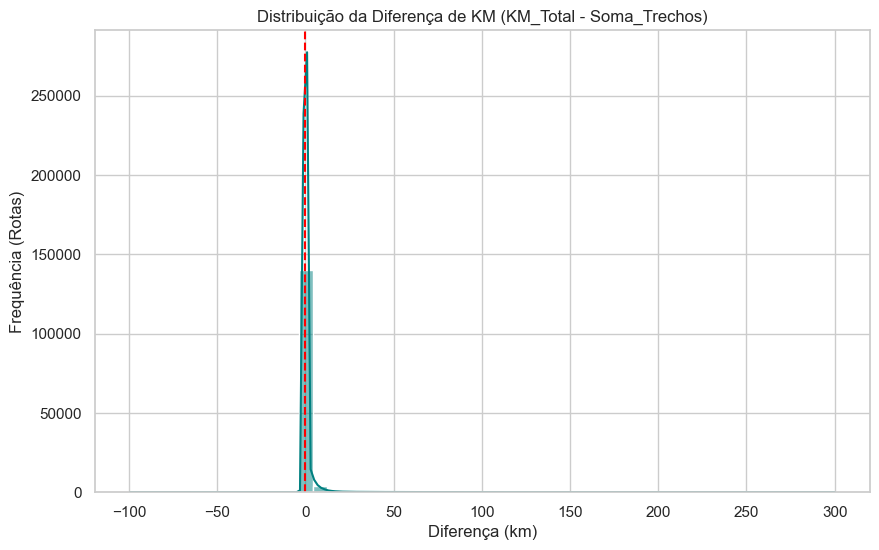

In [5]:
# B. Análise de Retorno à Base (Divergência de KM)
print("\n--- Bloco B: Análise de Retorno à Base ---")

df_km_consolidado = df_bruto.group_by("codigo_rota").agg([
    pl.col("km_trecho").sum().alias("soma_km_trechos"),
    pl.col("km_total_rota").first().alias("km_total_informado")
]).with_columns([
    (pl.col("km_total_informado") - pl.col("soma_km_trechos")).alias("diff_km_retorno")
])

total_rotas = df_km_consolidado.height 
# Rotas onde o informado é MAIOR que a soma (Possível Retorno à Base)
possivel_retorno = df_km_consolidado.filter(pl.col("diff_km_retorno") > 0.1).height
# Rotas onde a soma é MAIOR que o informado (Erro de Dados/Truncagem)
erro_truncagem = df_km_consolidado.filter(pl.col("diff_km_retorno") < -0.1).height

print(f"Rotas com 'Km de Retorno' provável (Informado > Soma): {possivel_retorno:,} ({(possivel_retorno/total_rotas)*100:.2f}%)")
print(f"Rotas com erro de truncagem (Soma > Informado): {erro_truncagem:,} ({(erro_truncagem/total_rotas)*100:.2f}%)")

# Visualização da distribuição da diferença
df_plot = df_km_consolidado.filter(
    (pl.col("diff_km_retorno") > -100) & 
    (pl.col("diff_km_retorno") < 300) &
    (pl.col("diff_km_retorno").is_not_nan()) # Garante que não há NaNs
).select("diff_km_retorno").to_pandas()
plt.figure(figsize=(10, 6))

sns.histplot(data=df_plot, x="diff_km_retorno", bins=50, kde=True, color='teal')
plt.title("Distribuição da Diferença de KM (KM_Total - Soma_Trechos)")
plt.axvline(0, color='red', linestyle='--') # Linha no zero para referência
plt.xlabel("Diferença (km)")
plt.ylabel("Frequência (Rotas)")
plt.show()

df_km_consolidado.write_csv("../data/05_analysis/df_km_consolidado.csv")


As 13.357 rotas (8.51%) onde o Informado > Soma confirmam que o campo ``km_total_rota`` da base bruta contém o deslocamento de volta ao galpão. Esse "KM de Retorno" é um custo operacional real (Opex). Como ação, não seria adequado sobrescrever o ``km_total_rota``. Em vez disso, criar uma métrica calculada: ``km_retorno`` = max(0, ``km_total_rota`` - ``soma_km_trechos``). 

c) Inconsistência de Peso vs. Capacidade: A divergência no Peso Total (6.5%) pode indicar erros de escala (gramas vs. kg) ou pedidos cancelados que ainda constam na base bruta mas foram retirados do total da rota. É preciso comparar peso_kg_total_rota com a capacidade máxima do tipo_veiculo. Se o peso granular somado ultrapassar a capacidade do caminhão (ex: > 14t para um Truck), há registros duplicados de entregas na mesma rota.

In [6]:
# C. Inconsistência de Peso vs. Capacidade (Duplicados vs Escala)
print("\n--- Bloco C: Peso vs. Capacidade ---")

# Dicionário de Premissas (ajuste conforme o perfil operacional LogiPrime/RotaSul)
# Capacidades médias em KG
capacidades = {
    "VUC": 3000,
    "VAN": 1500,
    "TRUCK": 14000,
    "TOCO": 8000,
    "CARRETA": 28000
}

# Criando coluna de capacidade baseada no dicionário
df_peso_capacidade = df_bruto.group_by("codigo_rota").agg([
    pl.col("peso_kg_entrega").sum().alias("peso_real_somado"),
    pl.col("tipo_veiculo").first().alias("veiculo")
]).with_columns(
    pl.col("veiculo").replace(capacidades, default=15000).cast(pl.Float64).alias("capacidade_max")
)

# Identificando violações (Peso somado > Capacidade Max + 10% tolerância)
violacoes_peso = df_peso_capacidade.filter(pl.col("peso_real_somado") > pl.col("capacidade_max") * 1.1)
print(f"Rotas que excederam a capacidade física do veículo: {violacoes_peso.height:,}")
if violacoes_peso.height > 0:
    print("Exemplo de violação:")
    display(violacoes_peso)


violacoes_peso.write_csv("../data/05_analysis/violacoes_peso.csv")


--- Bloco C: Peso vs. Capacidade ---
Rotas que excederam a capacidade física do veículo: 10,200
Exemplo de violação:


codigo_rota,peso_real_somado,veiculo,capacidade_max
str,f64,str,f64
"""B_PR_20240227_B-CAR-00046""",52596.096065,"""CARRETA""",28000.0
"""B_SC_20240405_B-TRK-00016""",27256.673408,"""TRUCK""",14000.0
"""B_RS_20240222_B-TRK-00130""",28083.553082,"""TRUCK""",14000.0
"""B_PR_20240425_B-TRK-00006""",25493.407754,"""TRUCK""",14000.0
"""B_RS_20240426_B-TRK-00056""",26229.053874,"""TRUCK""",14000.0
…,…,…,…
"""B_RS_20240226_B-CAR-00024""",54720.496654,"""CARRETA""",28000.0
"""B_SC_20240201_B-TRK-00078""",27823.093798,"""TRUCK""",14000.0
"""B_SC_20240420_B-TRK-00076""",25397.125163,"""TRUCK""",14000.0


Ao analisar o resultado, é possivel verificar que as rotas com excesso de peso têm quase exatamente o dobro da capacidade (``TRUCK`` com ~28t em vez de 14t; ``CARRETA`` com ~56t em vez de 28t). Há uma duplicação massiva de registros de entrega. Cada pedido está sendo contado duas vezes na mesma rota. Será preciso de um passo de ``df.unique(subset=["codigo_rota", "seq_entrega", "pdv_id", "peso_kg_entrega"])`` para eliminar essa redundância antes de qualquer soma.

d) Análise de "Velocidade Infinita" ou "Viagem no Tempo" (Outliers Físicos): Hipótese a ser trabalhada é criar  uma coluna temporária velocidade_media = km_trecho / (tempo_trecho_min / 60). Registros com velocidade > 120 km/h em trechos urbanos indicam erro de geoprocessamento. Registros com km_trecho > 0 e tempo_trecho_min = 0 (velocidade infinita) quebram cálculos de produtividade.

In [7]:
# D. VelocidadeMédia e Outliers Físicos
print("\n--- Bloco D: Velocidade Infinita e Viagem no Tempo ---")

# Calculando velocidade em km/h (tempo está em min)
df_velocidade = df_bruto.filter(
    pl.col("km_trecho").is_not_null() & 
    pl.col("tempo_trecho_min").is_not_null()
).with_columns([
    (pl.col("km_trecho") / (pl.col("tempo_trecho_min") / 60)).alias("v_media_kmh")
])

# 1. Velocidade Infinita (Tempo = 0 com KM > 0)
v_infinita = df_bruto.filter((pl.col("tempo_trecho_min") == 0) & (pl.col("km_trecho") > 0)).height

# 2. Velocidades irreais (> 120 km/h)
v_irreal = df_velocidade.filter(pl.col("v_media_kmh") > 120).height

print(f"Registros com Velocidade Infinita (tempo=0, km>0): {v_infinita:,}")
print(f"Registros com Velocidade Irreal (>120 km/h): {v_irreal:,}")

# Insight para tratamento: Se v_irreal for alto, o tempo logado pode estar em 
# segundos em vez de minutos em algumas regiões, ou o GPS falhou.



--- Bloco D: Velocidade Infinita e Viagem no Tempo ---
Registros com Velocidade Infinita (tempo=0, km>0): 0
Registros com Velocidade Irreal (>120 km/h): 0


Não foram registrados nenhuma anomalia relacionada a velocidade durante o trajeto da viajem, podendo descartar essa hipótese na lista de regras de negócio que será aplicada para tratamento dos dados de análise. Além disso, é preciso eliminar todas as colunas terminadas em ``_txt``, pois o carregamento via Parquet já garantiu a tipagem correta dos dados numéricos.

e) Valores Nulos: Além das anomilias apontadas anteriormente, há uma parcela significativa de dados nulos (19590) devido a ausência de informações nas colunas, sendo elas:
| Coluna | Quantidade de Nulos | Porcentagem | Causa Provável |
|--------|---------------------|-------------|----------------|
| `tempo_trecho_min` | 28 | ~6,9% | Dado ausente em registros onde o trecho não foi percorrido (ex: primeira entrega do dia, onde `km_trecho` também é zero). |
| `km_ate_ponto` | 28 | ~6,9% | Ausente quando a entrega é a primeira do dia, pois não há deslocamento entre pontos. |
| `tempo_ate_ponto_min` | 28 | ~6,9% | Ausente junto com `km_ate_ponto`, pois sem deslocamento não há tempo associado. |
| `erro_negativo_km` | 405 | 100% | Coluna booleana indicando se há erro de quilometragem negativa. Como **não há registros com erro** (todos `false`), a coluna é inútil e 100% nula (ou constante). |
| `erro_negativo_tempo` | 405 | 100% | Similar à anterior, indica erro de tempo negativo. Todos os valores são `false`, portanto a coluna é redundante. |

Para esses dados, será definido o seguinte tratamento:
- Para km_ate_ponto e tempo_ate_ponto_min: Substituir os nulos por 0, já que representam a primeira entrega da rota (sem deslocamento prévio).
- Para tempo_trecho_min: Também pode ser preenchido com 0, pois o trecho percorrido é zero nesses casos.
- Para as colunas de erro negativo: Removê-las do dataset, pois não agregam valor analítico.

### 2. Validação de Performance do Tratamento (O Cenário "Depois")

Com base no diagnóstico na seção 1, foi contruido o script ``clean_data`` (src\processing\clean_data.py) que foi responsável por:
- **Remoção de Duplicação de Entregas**: Remoção de registros duplicados que estavam dobrando o peso das rotas.
- **Preservação do KM de Retorno**: Em vez de forçar a soma dos trechos como o total, passaremos a calcular o "KM de Retorno" quando o total informado for maior que a soma.
- **Tratamento de Truncagem**: Se a soma dos trechos for maior que o total informado, assumimos a soma como verdade.
- **Remoção de Redundância**: Exclusão definitiva das colunas ``_txt``.
- **Relatório Estendido**: Inclusão das métricas das 4 hipóteses no JSON de saída salvo em data\03_processed.
- **Tratamento de Valores Nulos**: Substituição dos valores nulos presentes devido a ausência de dados por 0 e remoção de colunas booleanas.

Com isso, o resultado final será a base de dados unificada das duas empresas, já tratados e pronta para seguir com as devidas análises. Para assegurar a confiabilidade da base para as próximas análises (caracterização de frota e estimativa de saving), retestamos as mesmas métricas de falha utilizando os dados processados.

In [8]:
# Validação da base limpa
nulos_restantes = df_limpo.null_count().sum_horizontal()[0]
negativos_restantes = df_limpo.filter((pl.col("km_trecho") < 0) | (pl.col("tempo_trecho_min") < 0)).height

df_nulos = df_limpo.filter(pl.any_horizontal(pl.all().is_null()))
df_nulos.write_csv("../data/05_analysis/df_nulos.csv")

# Teste de integridade recalculado
teste_integridade_limpo = df_limpo.group_by("codigo_rota").agg([
    pl.col("peso_kg_entrega").sum().alias("soma_peso"),
    pl.col("peso_kg_total_rota").first().alias("total_peso_informado")
])
erros_restantes = teste_integridade_limpo.filter((pl.col("soma_peso") - pl.col("total_peso_informado")).abs() > 0.1).height

print("--- Resultado da Validação na Camada 03_processed ---")
print(f"Valores nulos restantes: {nulos_restantes}")
print(f"Valores negativos restantes: {negativos_restantes}")
print(f"Rotas com divergência de soma restante: {erros_restantes}")

if nulos_restantes == 0 and negativos_restantes == 0 and erros_restantes == 0:
    print("\n CONCLUSÃO: Base de dados 100% íntegra, corrigida e pronta para análise de perfil e viabilidade (Notebook 02).")
else:
    print("\n ALERTA: Ainda existem anomalias na base que requerem revisão no script de processamento.")

--- Resultado da Validação na Camada 03_processed ---
Valores nulos restantes: 0
Valores negativos restantes: 0
Rotas com divergência de soma restante: 0

 CONCLUSÃO: Base de dados 100% íntegra, corrigida e pronta para análise de perfil e viabilidade (Notebook 02).
